# Làm sạch và Khám phá Dữ liệu Chất lượng Không khí TP.HCM

## 0. Import Thư viện

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## 1. Thông tin tổng quan về dữ liệu

In [39]:
# Đọc dữ liệu
df = pd.read_csv('../data/raw/Air Quality Ho Chi Minh City.csv')
print(f"Số dòng: {df.shape[0]}, Số cột: {df.shape[1]}")

print("=== DATA TYPES ===")
display(df.dtypes)

print("=== 5 DÒNG ĐẦU TIÊN ===")
display(df.head())
print("=== 5 DÒNG CUỐI CÙNG ===")
display(df.tail())

print("=== THỐNG KÊ DỮ LIỆU ĐỊNH LƯỢNG ===")
display(df.describe())

print("=== DỮ LIỆU ĐỊNH TÍNH ===")
print(f"Cột 'date': {df['date'].nunique()} giá trị duy nhất")
print(f"Cột 'Station_No': {df['Station_No'].nunique()} trạm: {sorted(df['Station_No'].unique())}")
df.describe(include='object')

print("=== INFO ===")
df.info()

Số dòng: 52548, Số cột: 10
=== DATA TYPES ===


date            object
Station_No       int64
TSP            float64
PM2.5          float64
O3             float64
CO             float64
NO2            float64
SO2            float64
Temperature    float64
Humidity       float64
dtype: object

=== 5 DÒNG ĐẦU TIÊN ===


,date,Station_No,TSP,PM2.5,O3,CO,NO2,SO2,Temperature,Humidity
0,23-02-2021 21:00,1,32.935714,15.604762,55.431381,1330.451429,112.740762,393.000000,28.361905,63.188095
1,23-02-2021 22:00,1,30.932353,14.594118,58.197176,1200.603529,112.366471,377.588235,28.320588,63.773529
2,23-02-2021 23:00,1,27.645000,13.436667,55.029433,1177.897000,112.700433,372.476667,28.336667,64.205000
3,24-02-2021 00:00,1,24.380000,12.365000,54.767700,1267.476000,112.480867,389.070000,28.305000,64.735000
4,24-02-2021 01:00,1,22.521667,11.636667,53.786200,1322.293000,114.331500,393.000000,28.300000,65.188333


=== 5 DÒNG CUỐI CÙNG ===


,date,Station_No,TSP,PM2.5,O3,CO,NO2,SO2,Temperature,Humidity
52543,21-06-2022 13:00,6,21.526667,10.201667,100.080283,1007.907000,73.962600,146.720000,33.496667,60.470000
52544,21-06-2022 14:00,6,26.590000,11.250000,119.612133,1262.319000,96.609333,181.216667,33.026667,62.556667
52545,21-06-2022 15:00,6,27.606667,11.355000,119.448550,1457.330000,100.310600,212.220000,33.106667,62.175000
52546,21-06-2022 16:00,6,37.433333,15.048333,125.730150,2125.257000,128.383767,350.643333,31.406667,70.605000
52547,21-06-2022 17:00,6,27.810811,12.256757,123.085405,2180.187568,135.707459,357.594595,29.645946,75.578378


=== THỐNG KÊ DỮ LIỆU ĐỊNH LƯỢNG ===


,Station_No,TSP,PM2.5,O3,CO,NO2,SO2,Temperature,Humidity
count,52548.000000,52488.000000,52548.000000,41938.000000,43483.000000,46882.000000,41542.000000,48111.000000,48116.000000
mean,3.536062,43.550369,21.126031,94.229522,993.923726,96.444586,224.611910,27.812098,63.559275
std,1.695122,35.513882,14.229703,37.535105,615.692946,71.569328,114.412342,4.291604,25.718395
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.620000,18.491667,11.320000
25%,2.000000,24.638333,12.520000,71.667044,699.432450,54.076133,140.606667,25.858333,56.558333
50%,4.000000,38.775000,17.475000,90.232567,789.555800,78.855800,193.880000,28.083333,70.615000
75%,5.000000,57.097115,25.636667,112.669312,1112.575000,113.672800,286.016667,30.680000,82.355000
max,6.000000,938.198333,403.688333,377.288600,21092.570770,461.090000,699.976667,42.808333,99.283333


=== DỮ LIỆU ĐỊNH TÍNH ===
Cột 'date': 10452 giá trị duy nhất
Cột 'Station_No': 6 trạm: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52548 entries, 0 to 52547
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         52548 non-null  object 
 1   Station_No   52548 non-null  int64  
 2   TSP          52488 non-null  float64
 3   PM2.5        52548 non-null  float64
 4   O3           41938 non-null  float64
 5   CO           43483 non-null  float64
 6   NO2          46882 non-null  float64
 7   SO2          41542 non-null  float64
 8   Temperature  48111 non-null  float64
 9   Humidity     48116 non-null  float64
dtypes: float64(8), int64(1), object(1)
memory usage: 4.0+ MB


## 2. Kiểm tra Missing Data và Chiến lược xử lý

### 2.1 Tổng quan Missing Data

In [40]:
# Kiểm tra missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print("=== MISSING DATA ===")
print(missing_df if len(missing_df) > 0 else "Không có missing data")

=== MISSING DATA ===
             Missing Count  Missing %
SO2                  11006      20.94
O3                   10610      20.19
CO                    9065      17.25
NO2                   5666      10.78
Temperature           4437       8.44
Humidity              4432       8.43
TSP                     60       0.11


- Vì đây là dữ liệu thuộc kiểu time series và lượng dữ liệu bị thiếu rất lớn. Nên việc xóa các cột hay điền các giá trị đặc biệt (như mean, median, ...) là không hợp lý vì sẽ dẫn đến thiếu hụt dữ liệu hoặc là dữ liệu cao/thấp bất thường tại 1 thời điểm do giá trị điền đặt biệt này làm mất đi ý nghĩa của dữ liệu.
- Do đó, nhóm quyết định dùng phương pháp nội suy thời gian (giả định giữa 2 điểm đô đã biết, giá trị thay đổi tuyến tính theo thời gian). Điều này có tỷ lệ đúng rất cao với dữ liệu môi trường đo theo giờ, vì:
    - Khoảng thời gian giữa các lần đo chỉ 1 giờ, nên sai số nội suy rất nhỏ.
    - Các hiện tượng khí tượng/ô nhiễm biến thiên liên tục và không gián đoạn.

### 2.2 Thực hiện xử lý Missing Data

In [41]:
df['datetime_temp'] = pd.to_datetime(df['date'], format='%d-%m-%Y %H:%M')
df = df.sort_values(['Station_No', 'datetime_temp']).reset_index(drop=True)

numeric_cols = ['TSP', 'PM2.5', 'O3', 'CO', 'NO2', 'SO2', 'Temperature', 'Humidity']

print("=== XỬ LÝ MISSING DATA ===")
df_indexed = df.set_index('datetime_temp')
for col in numeric_cols:
    before = df[col].isnull().sum()
    # Tách dữ liệu thành 6 trạm, nhằm không trộn lẫn dữ liệu giữa các trạm
    df[col] = df_indexed.groupby('Station_No')[col].transform(
        lambda x: x.interpolate(method='time')
    ).values
    after = df[col].isnull().sum()
    if before > 0:
        print(f"  {col}: {before} --> {after} missing (đã fill {before - after})")

=== XỬ LÝ MISSING DATA ===
  TSP: 60 --> 0 missing (đã fill 60)
  O3: 10610 --> 0 missing (đã fill 10610)
  CO: 9065 --> 0 missing (đã fill 9065)
  NO2: 5666 --> 0 missing (đã fill 5666)
  SO2: 11006 --> 0 missing (đã fill 11006)
  Temperature: 4437 --> 0 missing (đã fill 4437)
  Humidity: 4432 --> 0 missing (đã fill 4432)


In [42]:
# Dọn cột tạm
df.drop(columns=['datetime_temp'], inplace=True, errors='ignore')

# Kết quả
remaining = df[numeric_cols].isnull().sum().sum()
print(f"=== KẾT QUẢ CUỐI CÙNG ===")
print(f"Tổng missing còn lại: {remaining}")
print(f"Shape: {df.shape}")
if remaining > 0:
    print("Vẫn còn missing --> drop các dòng này")
    df.dropna(inplace=True)
    print(f"Shape sau drop: {df.shape}")
else:
    print("Đã xử lý hoàn toàn missing data!")

=== KẾT QUẢ CUỐI CÙNG ===
Tổng missing còn lại: 0
Shape: (52548, 10)
Đã xử lý hoàn toàn missing data!


## 3. Kiểm tra Duplicate và Chiến lược xử lý

In [43]:
# Kiểm tra duplicate
dup_count = df.duplicated().sum()
print(f"=== DUPLICATE ===")
print(f"Số dòng trùng lặp hoàn toàn: {dup_count}")

# Kiểm tra duplicate theo date + Station_No
dup_key = df.duplicated(subset=['date', 'Station_No']).sum()
print(f"Số dòng trùng theo (date, Station_No): {dup_key}")

if dup_count > 0:
    print(f"\nMẫu các dòng trùng lặp:")
    print(df[df.duplicated(keep=False)].head(10))

=== DUPLICATE ===
Số dòng trùng lặp hoàn toàn: 0
Số dòng trùng theo (date, Station_No): 0


## 4. Format lại dữ liệu và Ép kiểu

In [44]:
# Kiểm tra kiểu dữ liệu hiện tại
print("=== KIỂU DỮ LIỆU HIỆN TẠI ===")
print(df.dtypes)
print(f"Mẫu cột date: {df['date'].head(3).tolist()}")

=== KIỂU DỮ LIỆU HIỆN TẠI ===
date            object
Station_No       int64
TSP            float64
PM2.5          float64
O3             float64
CO             float64
NO2            float64
SO2            float64
Temperature    float64
Humidity       float64
dtype: object
Mẫu cột date: ['23-02-2021 21:00', '23-02-2021 22:00', '23-02-2021 23:00']


In [45]:
# Tách cột date thành Date và Hour
df['datetime'] = pd.to_datetime(df['date'], format='%d-%m-%Y %H:%M')
df['Date'] = df['datetime'].dt.date
df['Hour'] = df['datetime'].dt.hour
df['Date'] = pd.to_datetime(df['Date'])
df.drop(columns=['date', 'datetime'], inplace=True)

cols = ['Date', 'Hour', 'Station_No', 'TSP', 'PM2.5', 'O3', 'CO', 'NO2', 'SO2', 'Temperature', 'Humidity']
df = df[cols]

print("=== SAU KHI TÁCH DATE VÀ HOUR ===")
print(df.dtypes)
print()
df.head()

=== SAU KHI TÁCH DATE VÀ HOUR ===
Date           datetime64[ns]
Hour                    int32
Station_No              int64
TSP                   float64
PM2.5                 float64
O3                    float64
CO                    float64
NO2                   float64
SO2                   float64
Temperature           float64
Humidity              float64
dtype: object



,Date,Hour,Station_No,TSP,PM2.5,O3,CO,NO2,SO2,Temperature,Humidity
0,2021-02-23,21,1,32.935714,15.604762,55.431381,1330.451429,112.740762,393.000000,28.361905,63.188095
1,2021-02-23,22,1,30.932353,14.594118,58.197176,1200.603529,112.366471,377.588235,28.320588,63.773529
2,2021-02-23,23,1,27.645000,13.436667,55.029433,1177.897000,112.700433,372.476667,28.336667,64.205000
3,2021-02-24,0,1,24.380000,12.365000,54.767700,1267.476000,112.480867,389.070000,28.305000,64.735000
4,2021-02-24,1,1,22.521667,11.636667,53.786200,1322.293000,114.331500,393.000000,28.300000,65.188333


In [46]:
# Ép kiểu
df['Station_No'] = df['Station_No'].astype('category')
df['Hour'] = df['Hour'].astype(int)

print("=== KIỂU DỮ LIỆU SAU KHI ÉP KIỂU ===")
print(df.dtypes)
print()
print(f"Date range: {df['Date'].min()} -> {df['Date'].max()}")
print(f"Hour range: {df['Hour'].min()} -> {df['Hour'].max()}")
print(f"Stations: {df['Station_No'].cat.categories.tolist()}")

=== KIỂU DỮ LIỆU SAU KHI ÉP KIỂU ===
Date           datetime64[ns]
Hour                    int64
Station_No           category
TSP                   float64
PM2.5                 float64
O3                    float64
CO                    float64
NO2                   float64
SO2                   float64
Temperature           float64
Humidity              float64
dtype: object

Date range: 2021-02-23 00:00:00 -> 2022-06-21 00:00:00
Hour range: 0 -> 23
Stations: [1, 2, 3, 4, 5, 6]


## 5. Kiểm tra Outlier

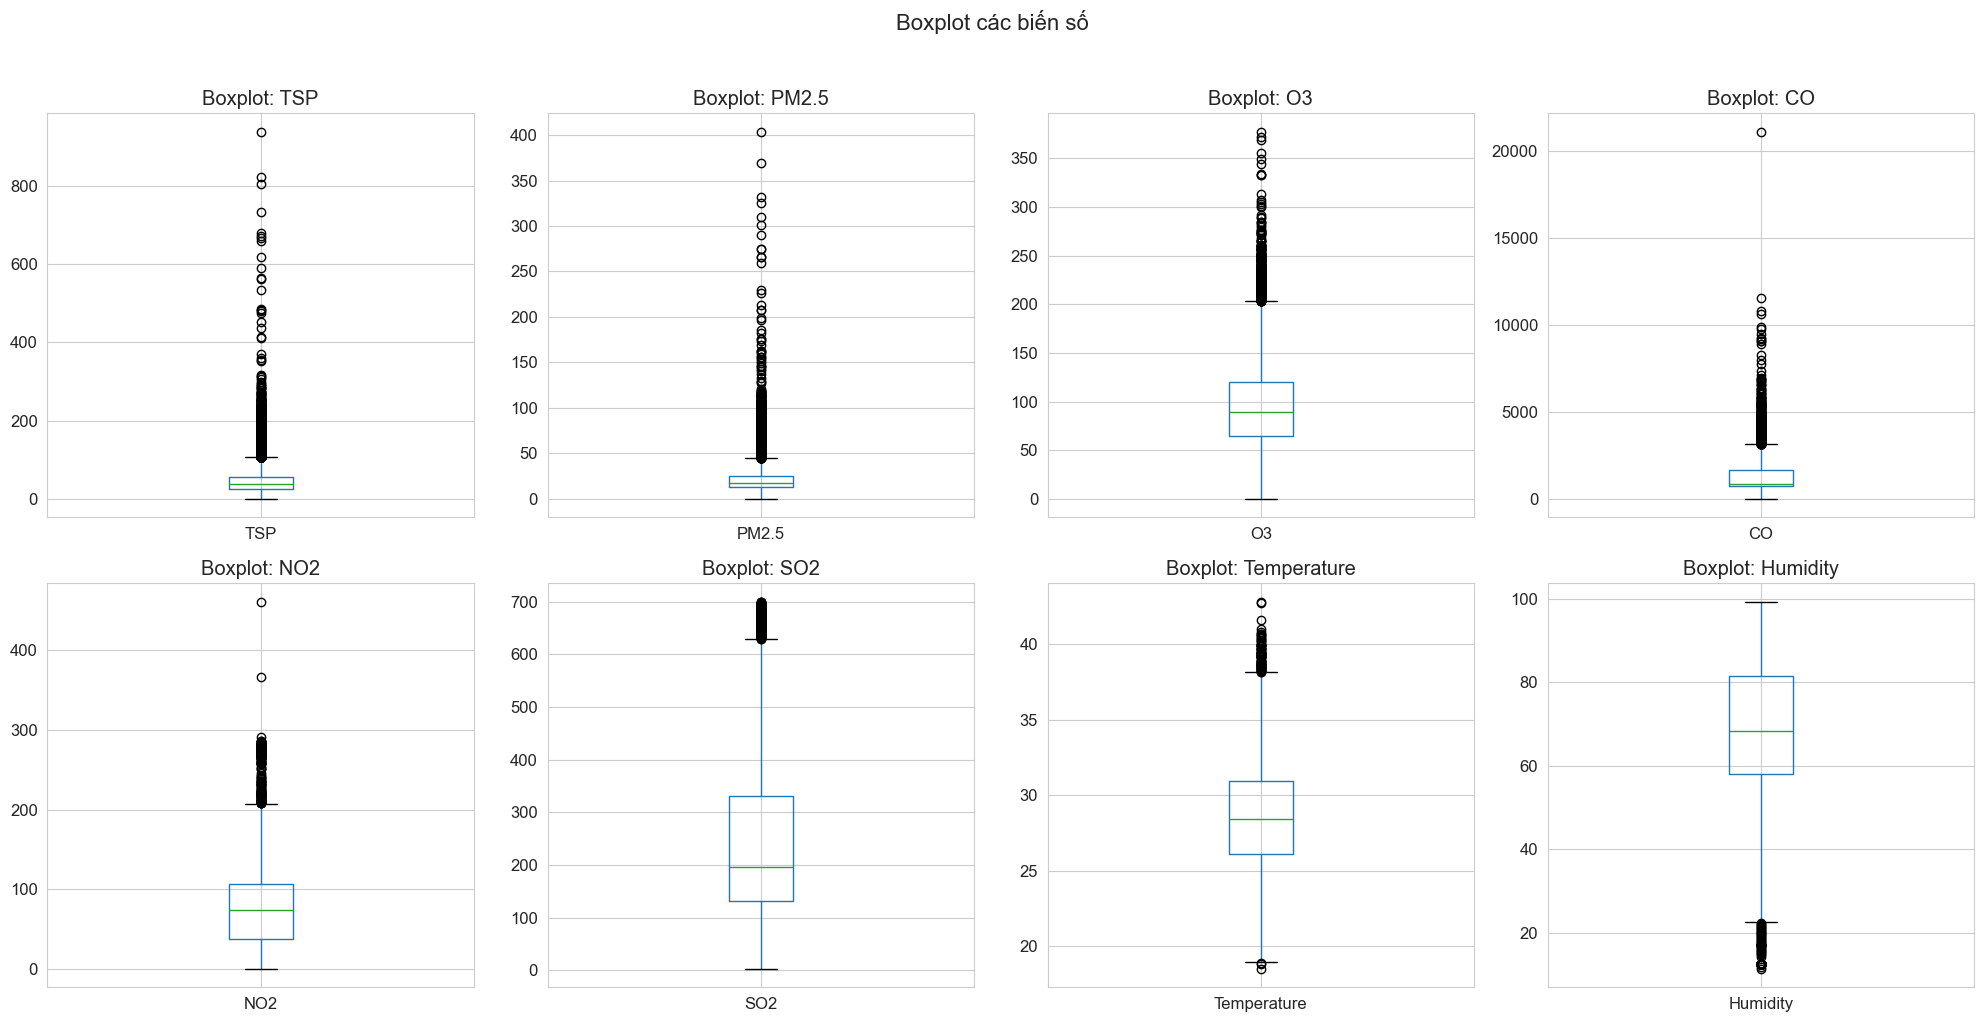

In [47]:
# Boxplot cho các cột số
numeric_cols = ['TSP', 'PM2.5', 'O3', 'CO', 'NO2', 'SO2', 'Temperature', 'Humidity']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(f'Boxplot: {col}')
plt.suptitle('Boxplot các biến số', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

- Các chỉ số outlier là bình thường, nó phản ánh các sự kiện thực tế có thật. Do đó, Nhóm quyết định không loại bỏ bất kỳ outlier nào vì nó sẽ làm mất đi các thông tin quan trọng hoặc thú vị.

## 6. Kiểm tra tính nhất quán của dữ liệu

In [48]:
# Kiểm tra phạm vi hợp lý
print("=== KIỂM TRA TÍNH NHẤT QUÁN ===")
numeric_cols = ['TSP', 'PM2.5', 'O3', 'CO', 'NO2', 'SO2', 'Temperature', 'Humidity']

print("1. Phạm vi giá trị:")
for col in numeric_cols:
    print(f"  {col}: [{df[col].min():.2f}, {df[col].max():.2f}]")

print("2. Station_No:")
station_counts = df['Station_No'].value_counts().sort_index()
for s, c in station_counts.items():
    print(f"  Trạm {s}: {c} bản ghi")

print(f"3. Hour: {df['Hour'].min()} - {df['Hour'].max()}")

print("4. Date liên tục:")
date_range = pd.date_range(df['Date'].min(), df['Date'].max())
missing_dates = set(date_range) - set(df['Date'].unique())
print(f"  Ngày trong range: {len(date_range)}, Có dữ liệu: {df['Date'].nunique()}, Thiếu: {len(missing_dates)}")

invalid_humidity = df[(df['Humidity'] < 0) | (df['Humidity'] > 100)]
print(f"5. Humidity ngoài [0, 100]: {len(invalid_humidity)} dòng")

inconsistent = df[df['PM2.5'] > df['TSP']]
print(f"6. PM2.5 > TSP: {len(inconsistent)} dòng")


=== KIỂM TRA TÍNH NHẤT QUÁN ===
1. Phạm vi giá trị:
  TSP: [0.00, 938.20]
  PM2.5: [0.00, 403.69]
  O3: [0.00, 377.29]
  CO: [0.00, 21092.57]
  NO2: [0.00, 461.09]
  SO2: [2.62, 699.98]
  Temperature: [18.49, 42.81]
  Humidity: [11.32, 99.28]
2. Station_No:
  Trạm 1: 7892 bản ghi
  Trạm 2: 9357 bản ghi
  Trạm 3: 8418 bản ghi
  Trạm 4: 9951 bản ghi
  Trạm 5: 7431 bản ghi
  Trạm 6: 9499 bản ghi
3. Hour: 0 - 23
4. Date liên tục:
  Ngày trong range: 484, Có dữ liệu: 458, Thiếu: 26
5. Humidity ngoài [0, 100]: 0 dòng
6. PM2.5 > TSP: 8139 dòng


**Nhận định sau khi kiểm tra tính nhất quản của dữ liệu:** $\newline$
1, Phạm vi giá trị là hợp lý $\newline$
2, Tỷ lệ chênh lệch ~25% giữa trạm nhiều nhất và ít nhất là bình thường. Vì mỗi trạm có thời gian bắt đầu vận hành khác nhau hoặc downtime khác nhau $\newline$
3, Thời gian 0-23h là hợp lý $\newline$
4, Trong tổng cộng 484 ngày thì thiếu 26 ngày (~5.4%). Đây không phải lỗi, chỉ là những ngày trạm không ghi dữ liệu (bảo trì, mất điện,...) $\newline$
5, Giá trị Humidity là hợp lý $\newline$
6, PM2.5 > TSP:
- PM2.5 là một phần của TSP (bụi mịn nằm trong tổng bụi lơ lửng)
- PM2.5 > TSP về mặt vật lý không thể xảy ra
- Do đó cần kiểm tra chi tiết

### Kiểm tra chi tiết vấn đề PM2.5 > TSP

--- Tỷ lệ lỗi / tổng bản ghi mỗi trạm ---
  Trạm 1: 95/7892 = 1.2%
  Trạm 2: 0/9357 = 0.0%
  Trạm 3: 8044/8418 = 95.6%
  Trạm 4: 0/9951 = 0.0%
  Trạm 5: 0/7431 = 0.0%
  Trạm 6: 0/9499 = 0.0%
--- Mức chênh lệch PM2.5 - TSP ---
  Mean:   23.73
  Median: 18.48
  Min:    0.03
  Max:    207.81
--- Mẫu dữ liệu Trạm 3 (bị lỗi) ---
            Date  TSP      PM2.5
17623 2021-04-09  0.0  45.160000
17624 2021-04-09  0.0  48.665000
17625 2021-04-09  0.0  43.240000
17626 2021-04-09  0.0  37.410000
17627 2021-04-09  0.0  43.718333
17628 2021-04-09  0.0  49.478333
17629 2021-04-09  0.0  52.086667
17630 2021-04-09  0.0  48.151667
17631 2021-04-10  0.0  44.490000
17632 2021-04-10  0.0  53.223333
--- So sánh trung bình TSP và PM2.5 ---
  Trạm 1: TSP=58.1, PM2.5=20.8, Tỷ lệ PM2.5/TSP=0.36
  Trạm 2: TSP=45.3, PM2.5=19.2, Tỷ lệ PM2.5/TSP=0.42
  Trạm 3: TSP=1.9, PM2.5=23.5, Tỷ lệ PM2.5/TSP=12.65
  Trạm 4: TSP=64.7, PM2.5=26.5, Tỷ lệ PM2.5/TSP=0.41
  Trạm 5: TSP=39.0, PM2.5=15.1, Tỷ lệ PM2.5/TSP=0.39
  Trạm

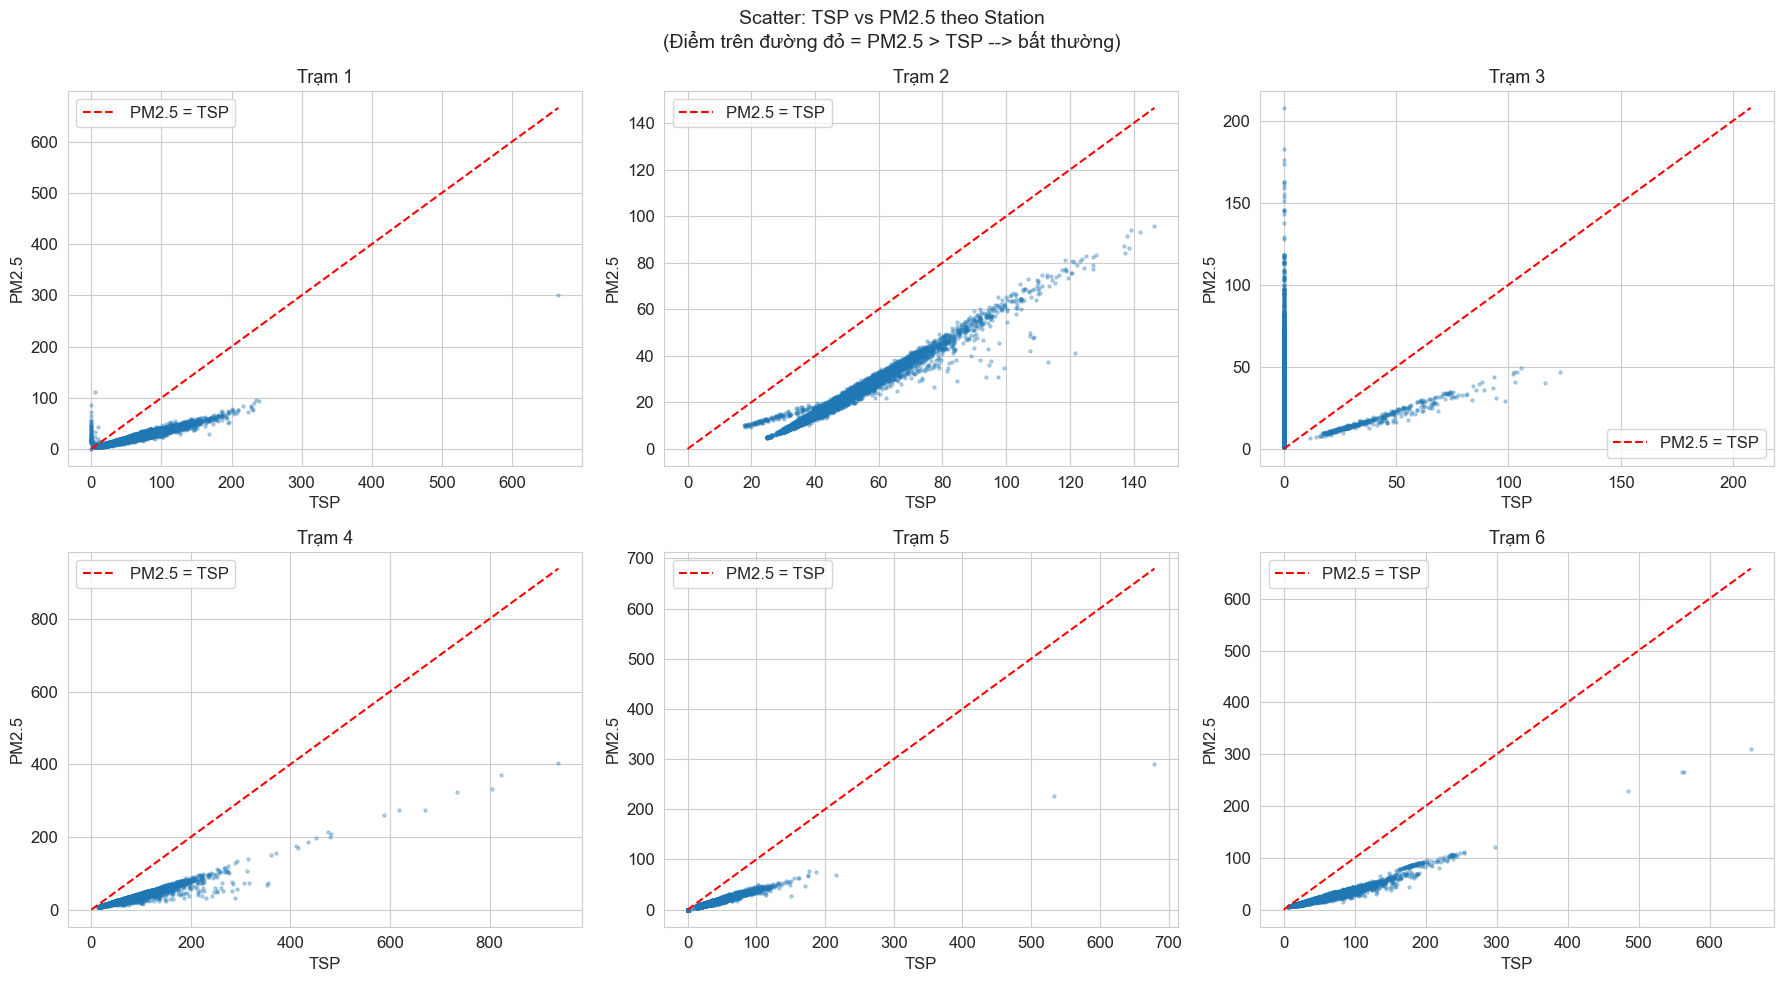

In [50]:
print("--- Tỷ lệ lỗi / tổng bản ghi mỗi trạm ---")
for station in sorted(df['Station_No'].unique()):
    total = len(df[df['Station_No'] == station])
    error = len(inconsistent[inconsistent['Station_No'] == station])
    print(f"  Trạm {station}: {error}/{total} = {error/total*100:.1f}%")

print("--- Mức chênh lệch PM2.5 - TSP ---")
inconsistent_diff = inconsistent['PM2.5'] - inconsistent['TSP']
print(f"  Mean:   {inconsistent_diff.mean():.2f}")
print(f"  Median: {inconsistent_diff.median():.2f}")
print(f"  Min:    {inconsistent_diff.min():.2f}")
print(f"  Max:    {inconsistent_diff.max():.2f}")

print("--- Mẫu dữ liệu Trạm 3 (bị lỗi) ---")
s3_error = df[(df['Station_No'] == 3) & (df['PM2.5'] > df['TSP'])][['Date', 'TSP', 'PM2.5']].head(10)
print(s3_error)

print("--- So sánh trung bình TSP và PM2.5 ---")
for station in sorted(df['Station_No'].unique()):
    s = df[df['Station_No'] == station]
    print(f"  Trạm {station}: TSP={s['TSP'].mean():.1f}, PM2.5={s['PM2.5'].mean():.1f}, "
          f"Tỷ lệ PM2.5/TSP={s['PM2.5'].mean()/s['TSP'].mean():.2f}")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, station in enumerate(sorted(df['Station_No'].unique())):
    s = df[df['Station_No'] == station]
    axes[i].scatter(s['TSP'], s['PM2.5'], alpha=0.3, s=5)
    # Vẽ đường y = x (PM2.5 = TSP)
    max_val = max(s['TSP'].max(), s['PM2.5'].max())
    axes[i].plot([0, max_val], [0, max_val], 'r--', label='PM2.5 = TSP')
    axes[i].set_title(f'Trạm {station}', fontsize=13)
    axes[i].set_xlabel('TSP')
    axes[i].set_ylabel('PM2.5')
    axes[i].legend()
plt.suptitle('Scatter: TSP vs PM2.5 theo Station\n(Điểm trên đường đỏ = PM2.5 > TSP --> bất thường)', fontsize=14)
plt.tight_layout()
plt.show()

- **Lỗi cảm biến TSP (Trạm 1 & 3):** Cảm biến đo tổng bụi (TSP) tại Trạm 3 bị hỏng gần như toàn thời gian và Trạm 1 bị lỗi gián đoạn (1.2%). Khi mất kết nối, hệ thống ghi nhận sai giá trị thành 0.0 thay vì báo thiếu dữ liệu (NaN). Không có hiện tượng đảo cột dữ liệu.
- **Dữ liệu PM2.5 hoàn toàn hợp lệ:** Cảm biến PM2.5 ở tất cả các trạm vẫn hoạt động chính xác. Tỷ lệ PM2.5/TSP trung bình đạt mức ~0.4, rất khớp với thực tế. Dữ liệu này là tài nguyên tốt và cần được giữ lại nguyên vẹn.
- **Bản chất vấn đề:** Đây là lỗi dữ liệu bị khuyết thiếu bị hệ thống ẩn dưới dạng số 0 ở cột TSP, chứ không phải dữ liệu đo đạc thực tế.
- **Hướng giải quyết:** Nhóm sẽ thực hiện điền TSP cho các số liệu gặp vấn đề bằng cách điện dựa PM2.5 và tỷ lệ trung bình của các trạm bình thường

### Chiến lược xử lý vấn đề PM2.5 > TSP

In [55]:
# Tính tỷ lệ trung bình PM2.5/TSP từ các trạm bình thường
normal_stations = df[df['Station_No'] != 3]
ratio = normal_stations['PM2.5'].mean() / normal_stations['TSP'].mean()

print(f"Tỷ lệ PM2.5/TSP trung bình (trạm bình thường): {ratio:.4f}")

# Sửa TSP cho Trạm 3: những dòng TSP = 0
mask = (df['Station_No'] == 3) & ((df['TSP'] == 0))
df.loc[mask, 'TSP'] = df.loc[mask, 'PM2.5'] / ratio

# Sửa Trạm 1 (95 dòng nhỏ): dùng cùng phương pháp
mask_s1 = (df['Station_No'] == 1) & (df['PM2.5'] > df['TSP'])
df.loc[mask_s1, 'TSP'] = df.loc[mask_s1, 'PM2.5'] / ratio
# Verify
print(f"=== Sau xử lý ===")
inconsistent = df[df['PM2.5'] > df['TSP']]
print("Tỷ lệ lỗi / tổng bản ghi mỗi trạm")
for station in sorted(df['Station_No'].unique()):
    total = len(df[df['Station_No'] == station])
    error = len(inconsistent[inconsistent['Station_No'] == station])
    print(f"  Trạm {station}: {error}/{total} = {error/total*100:.1f}%")

print(f"Trạm 3 TSP mean: {df[df['Station_No']==3]['TSP'].mean():.1f}")
print(f"Trạm 3 tỷ lệ PM2.5/TSP: {df[df['Station_No']==3]['PM2.5'].mean()/df[df['Station_No']==3]['TSP'].mean():.2f}")

Tỷ lệ PM2.5/TSP trung bình (trạm bình thường): 0.4009
=== Sau xử lý ===
Tỷ lệ lỗi / tổng bản ghi mỗi trạm
  Trạm 1: 0/7892 = 0.0%
  Trạm 2: 0/9357 = 0.0%
  Trạm 3: 0/8418 = 0.0%
  Trạm 4: 0/9951 = 0.0%
  Trạm 5: 0/7431 = 0.0%
  Trạm 6: 0/9499 = 0.0%
Trạm 3 TSP mean: 58.4
Trạm 3 tỷ lệ PM2.5/TSP: 0.40


### Kiểm tra tổng quát lại dữ liệu

In [58]:
print("=== DỮ LIỆU SAU KHI KIỂM TRA NHẤT QUÁN ===")
display(df.describe().round(2))

=== DỮ LIỆU SAU KHI KIỂM TRA NHẤT QUÁN ===


,Date,Hour,TSP,PM2.5,O3,CO,NO2,SO2,Temperature,Humidity
count,52548,52548.00,52548.00,52548.00,52548.00,52548.00,52548.00,52548.00,52548.00,52548.00
mean,2021-11-05 09:17:00.232929792,11.50,52.67,21.13,88.90,1129.61,86.05,248.12,28.03,63.56
min,2021-02-23 00:00:00,0.00,0.00,0.00,0.00,0.00,0.00,2.62,18.49,11.32
25%,2021-06-27 00:00:00,6.00,32.09,12.52,64.62,716.06,38.05,130.56,26.10,57.88
50%,2021-11-25 00:00:00,12.00,43.37,17.48,89.55,877.07,73.84,196.94,28.45,68.24
75%,2022-02-28 00:00:00,17.00,63.31,25.64,120.14,1683.09,105.93,330.12,30.92,81.46
max,2022-06-21 00:00:00,23.00,938.20,403.69,377.29,21092.57,461.09,699.98,42.81,99.28
std,NaN,6.89,35.10,14.23,47.97,634.73,73.92,176.24,4.20,24.70


## 7. Export dữ liệu sạch

In [59]:
output_path = r'../data/cleaned'
os.makedirs(output_path, exist_ok=True)

output_file = os.path.join(output_path, 'Air_Quality_HCMC_Cleaned.csv')
df.to_csv(output_file, index=False)
print(f"Đã export: {output_file}")
print(f"Shape: {df.shape}")
df.head(10)

Đã export: ../data/cleaned\Air_Quality_HCMC_Cleaned.csv
Shape: (52548, 11)


,Date,Hour,Station_No,TSP,PM2.5,O3,CO,NO2,SO2,Temperature,Humidity
0,2021-02-23,21,1,32.935714,15.604762,55.431381,1330.451429,112.740762,393.000000,28.361905,63.188095
1,2021-02-23,22,1,30.932353,14.594118,58.197176,1200.603529,112.366471,377.588235,28.320588,63.773529
2,2021-02-23,23,1,27.645000,13.436667,55.029433,1177.897000,112.700433,372.476667,28.336667,64.205000
3,2021-02-24,0,1,24.380000,12.365000,54.767700,1267.476000,112.480867,389.070000,28.305000,64.735000
4,2021-02-24,1,1,22.521667,11.636667,53.786200,1322.293000,114.331500,393.000000,28.300000,65.188333
5,2021-02-24,2,1,22.143333,11.530000,55.814633,1358.392000,115.993933,394.310000,28.253333,65.561667
6,2021-02-24,3,1,21.571667,11.241667,54.800417,1309.687000,114.174667,393.000000,28.216667,65.925000
7,2021-02-24,4,1,20.988333,11.130000,53.851633,1270.914000,113.923733,393.000000,28.200000,66.291667
8,2021-02-24,5,1,20.960000,11.060000,52.804700,1263.656000,113.014100,393.000000,28.188333,66.583333
9,2021-02-24,6,1,21.341667,11.176667,54.309667,1322.675000,115.366600,399.550000,28.161667,66.906667
